In [1]:
# ==========================================
# Week 5 – Machine Learning
# Logistic Regression Implementation
# ==========================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
# -----------------------------
# 2. Dataset Preparation
# -----------------------------
# Synthetic binary classification dataset
np.random.seed(42)
X = 2 * np.random.rand(100, 1) - 1  # features in range [-1, 1]
y = (X > 0).astype(int)  # target: 1 if X>0 else 0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# -----------------------------
# 3. Math Behind Logistic Regression
# -----------------------------
"""
Logistic Regression models the probability of class 1 as:
    P(y=1|x) = σ(z) = 1 / (1 + e^(-z))
where z = θ0 + θ1*x (linear combination of input features)

Loss Function (Binary Cross-Entropy / Log Loss):
    L(θ) = -(1/m) * Σ [y*log(p) + (1-y)*log(1-p)]
Gradient Descent Update Rule:
    θ := θ - α * ∇L(θ)
where ∇L(θ) = (1/m) * X.T * (σ(Xθ) - y)
"""

'\nLogistic Regression models the probability of class 1 as:\n    P(y=1|x) = σ(z) = 1 / (1 + e^(-z))\nwhere z = θ0 + θ1*x (linear combination of input features)\n\nLoss Function (Binary Cross-Entropy / Log Loss):\n    L(θ) = -(1/m) * Σ [y*log(p) + (1-y)*log(1-p)]\nGradient Descent Update Rule:\n    θ := θ - α * ∇L(θ)\nwhere ∇L(θ) = (1/m) * X.T * (σ(Xθ) - y)\n'

In [4]:
# -----------------------------
# 4. Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
# -----------------------------
# 5. Logistic Regression – From Scratch
# -----------------------------
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None

    def fit(self, X, y):
        # Add bias term
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        m = X_b.shape[0]
        y = y.reshape(-1, 1)
        self.theta = np.zeros((X_b.shape[1], 1))  # initialize weights

        for i in range(self.n_iterations):
            z = X_b.dot(self.theta)
            h = sigmoid(z)
            gradient = (1/m) * X_b.T.dot(h - y)
            self.theta -= self.learning_rate * gradient

    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return sigmoid(X_b.dot(self.theta))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


In [6]:
# -----------------------------
# 6. Train From Scratch Logistic Regression
# -----------------------------
model_scratch = LogisticRegressionScratch(learning_rate=0.5, n_iterations=2000)
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)

# Accuracy Function
def accuracy(y_true, y_pred):
    return np.mean(y_true.reshape(-1,1) == y_pred)

print("From Scratch Logistic Regression Weights (theta):", model_scratch.theta.ravel())
print("From Scratch Accuracy:", accuracy(y_test, y_pred_scratch))

From Scratch Logistic Regression Weights (theta): [ 0.24599252 13.02284529]
From Scratch Accuracy: 1.0


In [10]:
# Fix y shapes for Scikit-Learn
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

In [11]:
# -----------------------------
# 7. Logistic Regression – Scikit-Learn
# -----------------------------

model_sklearn = LogisticRegression()
model_sklearn.fit(X_train, y_train_flat)
y_pred_sklearn = model_sklearn.predict(X_test)

# Print results
print("Scikit-Learn Coefficients:", model_sklearn.coef_)
print("Scikit-Learn Intercept:", model_sklearn.intercept_)
print("Scikit-Learn Accuracy:", accuracy(y_test_flat, y_pred_sklearn))

Scikit-Learn Coefficients: [[3.8545131]]
Scikit-Learn Intercept: [0.0997298]
Scikit-Learn Accuracy: 0.505


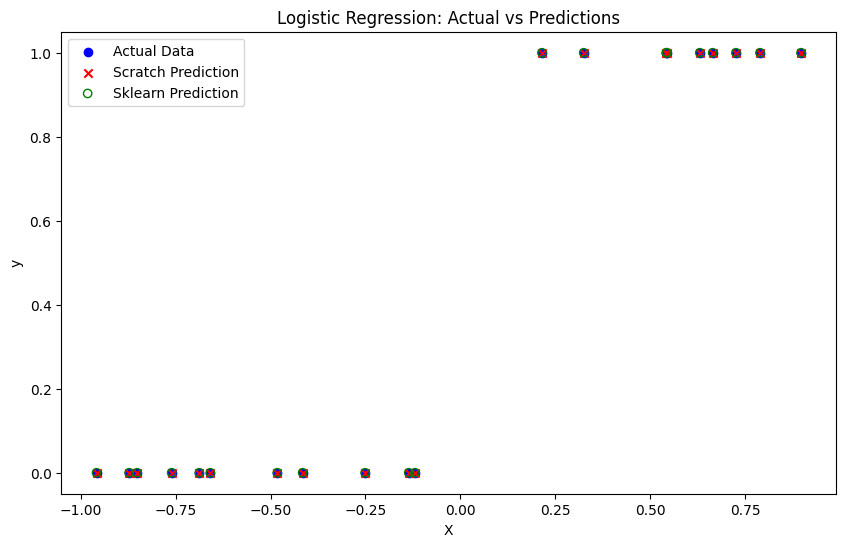

In [12]:
# -----------------------------
# 8. Visualization
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.scatter(X_test, y_pred_scratch, color='red', marker='x', label='Scratch Prediction')
plt.scatter(X_test, y_pred_sklearn, color='green', marker='o', facecolors='none', label='Sklearn Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Logistic Regression: Actual vs Predictions')
plt.legend()
plt.show()